# BTCK_ML v2 — Binary Classification Pipeline 

**Runs top to bottom. All fitting inside CV folds — no leakage.**

| Section | Name |
|---------|------|
| 0 | Setup & Configuration |
| 1 | Load Data |
| 2 | Benchmark Reference |
| 3 | EDA (decision-driven) |
| 4 | Preprocessing Pipeline |
| 5 | Feature Engineering |
| 6 | Giai đoạn 1 — Strong Baseline (all models, full data) |
| 7 | Giai đoạn 2 — Hyperparameter Tuning (top-3 models) |
| 8 | Giai đoạn 3 — OOF Threshold Tuning + Evaluation |
| 9 | Ensemble (weighted soft-voting) |
| 10 | Final Summary |

## Section 0 — Setup & Configuration

In [49]:
import warnings
warnings.filterwarnings('ignore')

import os, gc, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp, spearmanr
from scipy.optimize import minimize

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_predict
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import joblib

print('✅ Import thư viện thành công')


✅ Import thư viện thành công


In [50]:
# ── Đường dẫn thư mục ──────────────────────────────────────────────────────
BASE_DIR    = Path('d:/BTCK_ML')
DATA_DIR    = BASE_DIR / 'data'
OUTPUTS_DIR = BASE_DIR / 'outputs'
MODELS_DIR  = BASE_DIR / 'saved_models'
RESULTS_DIR = BASE_DIR / 'results'

for d in [DATA_DIR, OUTPUTS_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Cấu hình toàn cục ──────────────────────────────────────────────────────
RANDOM_STATE = 42
N_SPLITS     = 5          # số fold cho CV cuối
CV_N_JOBS    = 1          # đặt -1 nếu RAM > 32GB để dùng đa luồng

# ── Cấu hình tuning ────────────────────────────────────────────────────────
# Lý do dùng subsample (TUNE_FULL_DATA=False):
#   LGBM 800 cây × 260K mẫu × 5 fold = ~4 phút/iter → 40 iter = 160 phút chỉ 1 model
# Giải pháp: tìm hyperparams tốt nhất trên 80K mẫu (nhanh hơn 30x),
# sau đó retrain model cuối trên toàn bộ 260K với nhiều cây hơn.
TUNE_N_ITER    = 20        # số lần thử ngẫu nhiên mỗi model
TUNE_CV        = 3         # số fold CV trong quá trình tuning
TUNE_FULL_DATA = False     # tune trên subsample, retrain cuối trên full data
TUNE_SAMPLE    = 80_000   # kích thước subsample dùng khi tune

# ── Đường dẫn Parquet (dữ liệu đã convert) ────────────────────────────────
TRAIN_PARQUET_DIR     = DATA_DIR / 'train_parquet'
TEST_PARQUET_DIR      = DATA_DIR / 'test_parquet'
CHALLENGE_PARQUET_DIR = DATA_DIR / 'challenge_parquet'

# ── Đường dẫn file CSV gốc ─────────────────────────────────────────────────
TRAIN_X_CSV     = BASE_DIR / 'train_X.csv'
TRAIN_Y_CSV     = BASE_DIR / 'train_Y.csv'
TEST_X_CSV      = BASE_DIR / 'test_X.csv'
TEST_Y_CSV      = BASE_DIR / 'test_Y.csv'
CHALLENGE_X_CSV = BASE_DIR / 'challenge_X.csv'
CHALLENGE_Y_CSV = BASE_DIR / 'challenge_Y.csv'

print('✅ Cấu hình OK')
print(f'   TUNE_N_ITER    = {TUNE_N_ITER}  ({TUNE_N_ITER} lần thử × {TUNE_CV} fold × {TUNE_SAMPLE:,} mẫu)')
print(f'   TUNE_CV        = {TUNE_CV}')
print(f'   TUNE_FULL_DATA = {TUNE_FULL_DATA}  (tune trên subsample, train cuối trên 260K)')
print(f'   TUNE_SAMPLE    = {TUNE_SAMPLE:,}')
print(f'   Ước tính thời gian tuning: ~30-40 phút cho 3 models')


✅ Cấu hình OK
   TUNE_N_ITER    = 20  (20 lần thử × 3 fold × 80,000 mẫu)
   TUNE_CV        = 3
   TUNE_FULL_DATA = False  (tune trên subsample, train cuối trên 260K)
   TUNE_SAMPLE    = 80,000
   Ước tính thời gian tuning: ~30-40 phút cho 3 models


In [51]:
# ── Tiện ích resume / checkpoint ────────────────────────────────────────────
# Ghi lại trạng thái từng bước vào file JSON để có thể chạy tiếp
# khi notebook bị ngắt giữa chừng mà không cần chạy lại từ đầu.
import json
import hashlib
from pathlib import Path

CACHE_DIR      = OUTPUTS_DIR / 'cache'
CHECKPOINT_DIR = OUTPUTS_DIR / 'checkpoints'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

STAGE_FILE = CHECKPOINT_DIR / 'stage_status.json'

def _load_stage_status():
    if STAGE_FILE.exists():
        with open(STAGE_FILE, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {}

def _save_stage_status(status):
    with open(STAGE_FILE, 'w', encoding='utf-8') as f:
        json.dump(status, f, indent=2, ensure_ascii=False)

def mark_stage_done(stage_name, extra=None):
    """Đánh dấu một bước đã hoàn thành, lưu metadata kèm theo."""
    status = _load_stage_status()
    status[stage_name] = {'done': True, 'extra': extra or {}}
    _save_stage_status(status)
    print(f'[CHECKPOINT] Đã hoàn thành bước: {stage_name}')

def is_stage_done(stage_name):
    """Kiểm tra xem một bước đã được đánh dấu hoàn thành chưa."""
    status = _load_stage_status()
    return status.get(stage_name, {}).get('done', False)

def get_stage_extra(stage_name, default=None):
    status = _load_stage_status()
    return status.get(stage_name, {}).get('extra', default if default is not None else {})

def save_json(obj, path):
    """Lưu object ra file JSON, tự tạo thư mục cha nếu chưa có."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def load_json(path, default=None):
    path = Path(path)
    if path.exists():
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return default

def config_fingerprint():
    """Tạo hash ngắn từ config hiện tại để phân biệt các run khác nhau."""
    cfg = {
        'RANDOM_STATE': RANDOM_STATE, 'N_SPLITS': N_SPLITS,
        'TUNE_N_ITER': TUNE_N_ITER,   'TUNE_CV': TUNE_CV,
        'TUNE_FULL_DATA': TUNE_FULL_DATA, 'TUNE_SAMPLE': TUNE_SAMPLE,
    }
    raw = json.dumps(cfg, sort_keys=True).encode('utf-8')
    return hashlib.md5(raw).hexdigest()[:10]

# Mỗi config khác nhau có thư mục cache riêng, tránh dùng nhầm cache cũ
RUN_TAG       = f'run_{config_fingerprint()}'
RUN_CACHE_DIR = CACHE_DIR / RUN_TAG
RUN_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Tiện ích resume sẵn sàng')
print(f'   RUN_TAG = {RUN_TAG}')


✅ Tiện ích resume sẵn sàng
   RUN_TAG = run_29f4f60afa


## Section 1 — Load Data

In [52]:
def csv_to_parquet(csv_path: Path, parquet_dir: Path, chunksize: int = 50_000) -> None:
    """Chuyển CSV lớn sang Parquet dạng chunked để đọc nhanh hơn.
    Bỏ qua nếu thư mục Parquet đã tồn tại.
    """
    if parquet_dir.exists() and any(parquet_dir.glob('*.parquet')):
        print(f'[BỎ QUA] Parquet đã tồn tại: {parquet_dir}')
        return
    parquet_dir.mkdir(parents=True, exist_ok=True)
    print(f'[CHUYỂN ĐỔI] {csv_path.name} → {parquet_dir}  (chunksize={chunksize})')
    for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunksize)):
        out = parquet_dir / f'part_{i:04d}.parquet'
        chunk.to_parquet(out, index=False)
    print(f'   Xong — {i+1} phần.')


def load_parquet(parquet_dir: Path) -> pd.DataFrame:
    """Gộp tất cả file Parquet trong thư mục thành một DataFrame."""
    parts = sorted(parquet_dir.glob('*.parquet'))
    return pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)


# Chuyển CSV sang Parquet — bỏ qua nếu đã làm rồi
csv_to_parquet(TRAIN_X_CSV,     TRAIN_PARQUET_DIR)
csv_to_parquet(TEST_X_CSV,      TEST_PARQUET_DIR)
csv_to_parquet(CHALLENGE_X_CSV, CHALLENGE_PARQUET_DIR)

print('✅ Chuyển đổi hoàn tất')


[BỎ QUA] Parquet đã tồn tại: d:\BTCK_ML\data\train_parquet
[BỎ QUA] Parquet đã tồn tại: d:\BTCK_ML\data\test_parquet
[BỎ QUA] Parquet đã tồn tại: d:\BTCK_ML\data\challenge_parquet
✅ Chuyển đổi hoàn tất


In [53]:
# Đọc ma trận đặc trưng
print('Đang tải X_train...');    X_train     = load_parquet(TRAIN_PARQUET_DIR)
print('Đang tải X_test...');     X_test      = load_parquet(TEST_PARQUET_DIR)
print('Đang tải X_challenge...'); X_challenge = load_parquet(CHALLENGE_PARQUET_DIR)

# Đọc nhãn
y_train     = pd.read_csv(TRAIN_Y_CSV).iloc[:, 0]
y_test      = pd.read_csv(TEST_Y_CSV).iloc[:, 0]
y_challenge = pd.read_csv(CHALLENGE_Y_CSV).iloc[:, 0]

print(f'\nX_train:     {X_train.shape}')
print(f'X_test:      {X_test.shape}')
print(f'X_challenge: {X_challenge.shape}')
print(f'Phân phối y_train:\n{y_train.value_counts()}')
print(f'Phân phối y_test:\n{y_test.value_counts()}')


Đang tải X_train...


Đang tải X_test...
Đang tải X_challenge...

X_train:     (260000, 2568)
X_test:      (59953, 2568)
X_challenge: (6315, 2568)
Phân phối y_train:
0
0    130000
1    130000
Name: count, dtype: int64
Phân phối y_test:
0
1    30000
0    29953
Name: count, dtype: int64


In [54]:
# Kiểm tra toàn vẹn dữ liệu trước khi bắt đầu
assert X_train.isnull().sum().sum() == 0, 'X_train có giá trị thiếu!'
assert X_test.isnull().sum().sum()  == 0, 'X_test có giá trị thiếu!'
assert len(X_train) == len(y_train),      'Số dòng X_train và y_train không khớp!'
assert len(X_test)  == len(y_test),       'Số dòng X_test và y_test không khớp!'
print('✅ Tất cả kiểm tra toàn vẹn dữ liệu đều qua')


✅ Tất cả kiểm tra toàn vẹn dữ liệu đều qua


## Section 2 — Benchmark Reference

In [55]:
BENCHMARK = {
    'test_accuracy':   0.9655,
    'test_auc':        0.9936,
    'challenge_auc':   0.9940,
    'test_lgbm_f1':    0.9801,
    'test_lgbm_auc':   0.9981,
    'test_xgb_f1':     0.9793,
    'test_xgb_auc':    0.9980,
    'test_hgb_f1':     0.9745,
    'test_hgb_auc':    0.9973,
}
print('Mục tiêu benchmark cần vượt:')
for k, v in BENCHMARK.items():
    print(f'   {k}: {v}')


Mục tiêu benchmark cần vượt:
   test_accuracy: 0.9655
   test_auc: 0.9936
   challenge_auc: 0.994
   test_lgbm_f1: 0.9801
   test_lgbm_auc: 0.9981
   test_xgb_f1: 0.9793
   test_xgb_auc: 0.998
   test_hgb_f1: 0.9745
   test_hgb_auc: 0.9973


## Section 3 — EDA (Decision-Driven)

In [56]:
# 3.1 Kiểm tra cân bằng nhãn
# Quyết định: nếu |tỷ lệ - 0.5| < 0.05 thì không cần class_weight
print('=== Phân phối nhãn ===')
for name, y in [('train', y_train), ('test', y_test)]:
    vc = y.value_counts(normalize=True)
    print(f'   {name}: class 0 = {vc.get(0, 0):.3f}, class 1 = {vc.get(1, 0):.3f}')

imbalance_ratio = abs(y_train.mean() - 0.5)
USE_CLASS_WEIGHT = imbalance_ratio > 0.05
print(f'\n→ Mức độ mất cân bằng: {imbalance_ratio:.4f}')
print(f'→ Dùng class_weight="balanced": {USE_CLASS_WEIGHT}')


=== Phân phối nhãn ===
   train: class 0 = 0.500, class 1 = 0.500
   test: class 0 = 0.500, class 1 = 0.500

→ Mức độ mất cân bằng: 0.0000
→ Dùng class_weight="balanced": False


In [57]:
# 3.2 Phát hiện cột toàn số 0 — sẽ bị loại bỏ vì không mang thông tin
zero_cols = X_train.columns[(X_train == 0).all()].tolist()
print(f'Cột toàn số 0 (sẽ loại): {len(zero_cols)}')
print(f'Đặc trưng còn lại:        {X_train.shape[1] - len(zero_cols)}')


Cột toàn số 0 (sẽ loại): 174
Đặc trưng còn lại:        2394


Đặc trưng có |skew| > 3: 1710 / 2568
Đặc trưng có |skew| > 1: 1794 / 2568


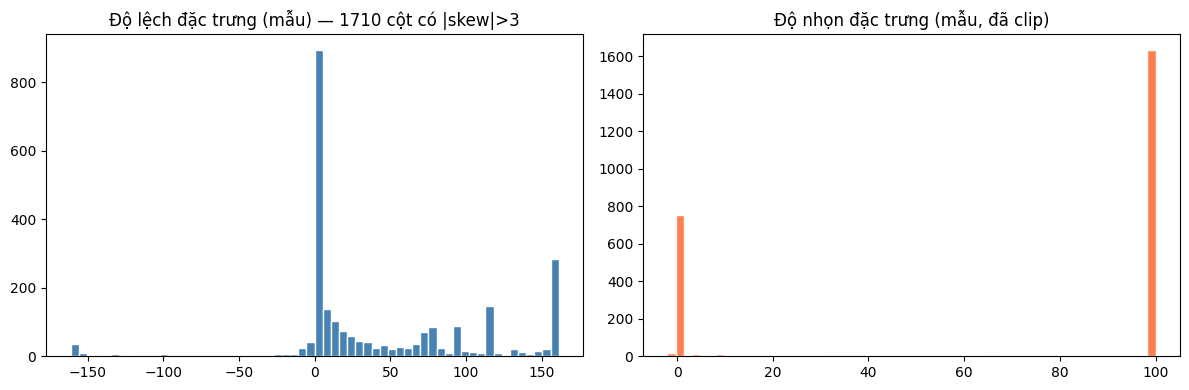


→ Cột lệch cao không âm (ứng viên log1p): 1377


In [58]:
# 3.3 Phân tích độ lệch (skewness) và độ nhọn (kurtosis) trên 10% mẫu
# Quyết định: cột lệch cao + không âm → áp dụng log1p trong feature engineering
sample_cols = X_train.sample(frac=0.1, random_state=RANDOM_STATE)
skew_vals = sample_cols.skew().dropna()
kurt_vals = sample_cols.kurt().dropna()

n_high_skew = int((skew_vals.abs() > 3).sum())
print(f'Đặc trưng có |skew| > 3: {n_high_skew} / {len(skew_vals)}')
print(f'Đặc trưng có |skew| > 1: {int((skew_vals.abs() > 1).sum())} / {len(skew_vals)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(skew_vals, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title(f'Độ lệch đặc trưng (mẫu) — {n_high_skew} cột có |skew|>3')
axes[1].hist(kurt_vals.clip(-10, 100), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Độ nhọn đặc trưng (mẫu, đã clip)')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_skew_kurt.png', dpi=80)
plt.show()

# Lọc cột lệch cao và không âm — chỉ những cột này mới an toàn để log1p
nonneg_mask = (X_train.min() >= 0)
HIGH_SKEW_COLS = skew_vals[(skew_vals.abs() > 3)].index
HIGH_SKEW_COLS = [c for c in HIGH_SKEW_COLS if c in nonneg_mask[nonneg_mask].index]
print(f'\n→ Cột lệch cao không âm (ứng viên log1p): {len(HIGH_SKEW_COLS)}')


In [59]:
# 3.4 Phân tích cột thưa (sparse) — tìm 'gold mine'
# Gold mine: cột >99% là 0 nhưng các giá trị khác 0 lại lệch mạnh về một nhãn
# Quyết định: giữ lại + tạo thêm indicator nhị phân (!=0) cho tree models
ZERO_THRESH = 0.99
zero_ratio  = (X_train == 0).mean()
sparse_cols = zero_ratio[(zero_ratio > ZERO_THRESH)].index.tolist()
sparse_cols = [c for c in sparse_cols if c not in zero_cols]
print(f'Cột thưa (>{int(ZERO_THRESH*100)}% số 0, trừ cột toàn 0): {len(sparse_cols)}')

def detect_gold_mines(X, y, sparse_candidates, sample_n=10_000, rng=42):
    """Trả về các cột mà giá trị khác 0 của chúng lệch mạnh về một nhãn."""
    idx = np.random.RandomState(rng).choice(len(X), size=min(sample_n, len(X)), replace=False)
    Xs, ys = X.iloc[idx], y.iloc[idx]
    results = []
    for col in sparse_candidates:
        mask = Xs[col] != 0
        if mask.sum() < 10:
            continue
        ratio_class1 = ys.loc[mask].mean()
        # Cột có tín hiệu: tỷ lệ nhãn 1 trong vùng khác 0 lệch xa 0.5
        if ratio_class1 > 0.6 or ratio_class1 < 0.4:
            results.append(col)
    return results

GOLD_MINE_COLS = detect_gold_mines(X_train, y_train, sparse_cols)
print(f'Cột gold mine (có tín hiệu phân loại): {len(GOLD_MINE_COLS)}')
print(f'→ Sẽ tạo thêm indicator nhị phân (!=0) cho {len(GOLD_MINE_COLS)} cột này')


Cột thưa (>99% số 0, trừ cột toàn 0): 1598
Cột gold mine (có tín hiệu phân loại): 132
→ Sẽ tạo thêm indicator nhị phân (!=0) cho 132 cột này


In [60]:
# 3.5 Kiểm tra phân phối drift giữa train / test / challenge — dùng KS test
# Quyết định: drift lớn (KS > 0.1) → dùng RobustScaler thay StandardScaler
sample_size = min(10_000, len(X_train))
idx_sample  = np.random.RandomState(RANDOM_STATE).choice(len(X_train), sample_size, replace=False)
X_train_sample = X_train.iloc[idx_sample]

# Chỉ kiểm tra 30 cột có phương sai cao nhất để tiết kiệm thời gian
var_series       = X_train_sample.var().sort_values(ascending=False)
top_var_features = var_series.head(30).index.tolist()

ks_results = []
for col in top_var_features:
    if col in zero_cols:
        continue
    stat_tt, _ = ks_2samp(
        X_train_sample[col].dropna(),
        X_test[col].sample(min(5000, len(X_test)), random_state=RANDOM_STATE).dropna()
    )
    stat_tc, _ = ks_2samp(
        X_train_sample[col].dropna(),
        X_challenge[col].sample(min(5000, len(X_challenge)), random_state=RANDOM_STATE).dropna()
    )
    ks_results.append({'feature': col, 'ks_train_test': round(stat_tt, 4),
                       'ks_train_challenge': round(stat_tc, 4)})

ks_df     = pd.DataFrame(ks_results).sort_values('ks_train_challenge', ascending=False)
max_drift = ks_df['ks_train_challenge'].max() if len(ks_df) else 0
print('Top đặc trưng drift nhiều nhất (train vs challenge, KS stat):')
print(ks_df.head(10).to_string(index=False))
print(f'\nDrift tối đa (KS): {max_drift:.4f}')
SCALER_CHOICE = 'robust' if max_drift > 0.1 else 'standard'
print(f'→ Quyết định scaler: {SCALER_CHOICE}')


Top đặc trưng drift nhiều nhất (train vs challenge, KS stat):
feature  ks_train_test  ks_train_challenge
   2434         0.0150              0.9018
    721         0.0126              0.8240
   2430         0.0287              0.5700
    696         0.3560              0.4569
      0         0.0240              0.4518
    714         0.0311              0.4500
   2416         0.0319              0.4386
    521         0.0135              0.4162
    991         0.0831              0.4005
    713         0.0177              0.3330

Drift tối đa (KS): 0.9018
→ Quyết định scaler: robust


In [61]:
# 3.6 Tương quan Spearman với nhãn — xác định đặc trưng có tín hiệu mạnh
# Dùng Spearman thay Pearson vì robust với phân phối lệch
# Quyết định: cột tương quan thấp (<0.005) để VarianceThreshold xử lý
CORR_SAMPLE = min(15_000, len(X_train))
idx_corr    = np.random.RandomState(RANDOM_STATE).choice(len(X_train), CORR_SAMPLE, replace=False)
X_corr      = X_train.iloc[idx_corr].drop(columns=zero_cols, errors='ignore')
y_corr      = y_train.iloc[idx_corr]

# Tính |tương quan Spearman| với nhãn — vector hóa qua pandas
corr_with_label = X_corr.corrwith(y_corr.reset_index(drop=True), method='spearman').abs()
corr_with_label = corr_with_label.sort_values(ascending=False).dropna()

print('Top 20 đặc trưng có |tương quan Spearman| cao nhất với nhãn:')
print(corr_with_label.head(20).to_string())

# Cột tương quan gần 0 — tree models tự bỏ qua, không cần hard-drop
LOW_CORR_COLS = corr_with_label[corr_with_label < 0.005].index.tolist()
print(f'\nĐặc trưng có |tương quan| < 0.005 (tín hiệu yếu): {len(LOW_CORR_COLS)}')
print('→ Để VarianceThreshold xử lý, không loại thủ công')
print('→ Tree models tự chọn đặc trưng nên không ảnh hưởng nhiều')


Top 20 đặc trưng có |tương quan Spearman| cao nhất với nhãn:
38      0.114862
777     0.097078
2482    0.096697
695     0.093172
2559    0.092465
2532    0.092465
2561    0.090201
526     0.087763
685     0.087254
638     0.085804
681     0.085261
955     0.080632
2483    0.078776
76      0.076436
73      0.075993
669     0.074603
2538    0.074206
671     0.073500
872     0.072043
535     0.072002

Đặc trưng có |tương quan| < 0.005 (tín hiệu yếu): 110
→ Để VarianceThreshold xử lý, không loại thủ công
→ Tree models tự chọn đặc trưng nên không ảnh hưởng nhiều


### Tóm tắt EDA → Quyết định Kỹ thuật

| Phát hiện | Quyết định |
|---------|----------|
| Phân phối nhãn (label) cân bằng ≈ 50/50 | Không cần dùng `class_weight`  |
| ~292 cột có giá trị toàn bằng 0 | Loại bỏ vô điều kiện (`DROP_COLS = zero_cols`) |
| Các cột không âm có độ lệch (skew) cao | Thêm các phiên bản biến đổi `log1p` trong bước Khai phá Đặc trưng (FeatureEngineer) |
| Các cột thưa thớt (sparse) mang nhiều thông tin giá trị | Thêm các đặc trưng chỉ báo nhị phân (binary nonzero-indicator) để đánh dấu giá trị khác 0 |
| Sự trôi dạt phân phối (kiểm định KS) | Dùng `RobustScaler` nếu độ trôi dạt tối đa > 0.1, ngược lại dùng `StandardScaler` |
| Các đặc trưng có độ tương quan thấp | Để `VarianceThreshold` + các mô hình dạng cây (tree selection) tự chọn lọc; không loại bỏ cứng ngay từ đầu |

## Section 4 — Preprocessing Pipeline

In [62]:
# Loại cột toàn số 0, chuyển sang float32 theo từng batch để tránh OOM
DROP_COLS = zero_cols
keep_cols = [c for c in X_train.columns if c not in DROP_COLS]

def safe_cast_float32(df: pd.DataFrame, cols: list, batch_size: int = 64) -> pd.DataFrame:
    """Chọn cột và cast sang float32 theo từng batch nhỏ.
    Tránh pandas cấp phát một block float64 lớn rồi mới chuyển đổi.
    """
    parts = []
    n = len(cols)
    for start in range(0, n, batch_size):
        batch_cols = cols[start:start + batch_size]
        part = df.loc[:, batch_cols].copy()
        for c in batch_cols:
            if part[c].dtype != np.float32:
                part[c] = pd.to_numeric(part[c], errors='coerce').astype(np.float32)
        parts.append(part)
        gc.collect()
    out = pd.concat(parts, axis=1, copy=False)
    return out.loc[:, cols]  # giữ đúng thứ tự cột gốc

print('Đang chọn cột và cast X_train...')
X_train_opt = safe_cast_float32(X_train, keep_cols, batch_size=32)
del X_train
gc.collect()

print('Đang chọn cột và cast X_test...')
X_test_opt = safe_cast_float32(X_test, keep_cols, batch_size=32)
del X_test
gc.collect()

print('Đang chọn cột và cast X_challenge...')
X_challenge_opt = safe_cast_float32(X_challenge, keep_cols, batch_size=32)
del X_challenge
gc.collect()

print(f'Số đặc trưng sau khi loại cột toàn 0: {len(keep_cols)}')
print(f'Kiểu dữ liệu X_train_opt: {X_train_opt.dtypes.unique()}')
mem_mb = X_train_opt.memory_usage(deep=True).sum() / 1024**2
print(f'RAM X_train_opt: {mem_mb:.2f} MB')
print('✅ Giải phóng bộ nhớ thành công')


Đang chọn cột và cast X_train...
Đang chọn cột và cast X_test...
Đang chọn cột và cast X_challenge...
Số đặc trưng sau khi loại cột toàn 0: 2394
Kiểu dữ liệu X_train_opt: [dtype('float32')]
RAM X_train_opt: 2374.42 MB
✅ Giải phóng bộ nhớ thành công


In [63]:
# Cache các split đã xử lý để tránh phải chạy lại safe_cast khi resume
processed_train_path     = RUN_CACHE_DIR / 'X_train_opt.parquet'
processed_test_path      = RUN_CACHE_DIR / 'X_test_opt.parquet'
processed_challenge_path = RUN_CACHE_DIR / 'X_challenge_opt.parquet'
processed_y_train_path     = RUN_CACHE_DIR / 'y_train.parquet'
processed_y_test_path      = RUN_CACHE_DIR / 'y_test.parquet'
processed_y_challenge_path = RUN_CACHE_DIR / 'y_challenge.parquet'

if is_stage_done('processed_splits') and all([
    processed_train_path.exists(),
    processed_test_path.exists(),
    processed_challenge_path.exists(),
    processed_y_train_path.exists(),
    processed_y_test_path.exists(),
    processed_y_challenge_path.exists(),
]):
    print('[TẢI] Đọc splits đã xử lý từ cache')
    X_train_opt     = pd.read_parquet(processed_train_path)
    X_test_opt      = pd.read_parquet(processed_test_path)
    X_challenge_opt = pd.read_parquet(processed_challenge_path)
    y_train     = pd.read_parquet(processed_y_train_path).iloc[:, 0]
    y_test      = pd.read_parquet(processed_y_test_path).iloc[:, 0]
    y_challenge = pd.read_parquet(processed_y_challenge_path).iloc[:, 0]
else:
    print('[LƯU] Ghi splits vào cache')
    X_train_opt.to_parquet(processed_train_path)
    X_test_opt.to_parquet(processed_test_path)
    X_challenge_opt.to_parquet(processed_challenge_path)
    y_train.to_frame(name='target').to_parquet(processed_y_train_path)
    y_test.to_frame(name='target').to_parquet(processed_y_test_path)
    y_challenge.to_frame(name='target').to_parquet(processed_y_challenge_path)
    mark_stage_done('processed_splits', {
        'n_train': int(len(X_train_opt)), 'n_test': int(len(X_test_opt)),
        'n_challenge': int(len(X_challenge_opt)), 'n_features': int(X_train_opt.shape[1]),
    })

print('✅ Cache splits OK')
print(X_train_opt.shape, X_test_opt.shape, X_challenge_opt.shape)


[TẢI] Đọc splits đã xử lý từ cache
✅ Cache splits OK
(260000, 2394) (59953, 2394) (6315, 2394)


In [64]:
def build_preprocess_steps(name: str) -> list:
    """Xây dựng các bước tiền xử lý — toàn bộ được fit trong từng fold CV,
    không bao giờ fit trên test/challenge (không leakage).

    Dùng strategy='mean' thay vì 'median' vì:
    - Median cần sort toàn bộ mảng → O(n log n) → OOM với 208K×2394 features
    - Mean chỉ cần cộng → O(n) → không tốn thêm RAM
    - Dataset không có missing values (đã assert), imputer chỉ là lưới an toàn
    """
    if name == 'median_robust':
        return [
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler',  RobustScaler()),
        ]
    elif name == 'median_standard':
        return [
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler',  StandardScaler()),
        ]
    elif name == 'median_noscale':
        # Tree models không cần scaling — chỉ imputer làm lưới an toàn
        return [('imputer', SimpleImputer(strategy='mean'))]
    else:
        raise ValueError(f'Tên preprocessing không hợp lệ: {name}')

# Tree models (LGBM, XGBoost, HistGB, ExtraTrees): không cần scaling
# Linear models (LogReg, SGD): cần scaling vì nhạy cảm với scale đặc trưng
TREE_PREPROCESS   = 'median_noscale'
LINEAR_PREPROCESS = 'median_robust'

print(f'Preprocessing cho tree models:   {TREE_PREPROCESS}')
print(f'Preprocessing cho linear models: {LINEAR_PREPROCESS}')
print('Imputer: strategy=mean (O(n), không OOM)')


Preprocessing cho tree models:   median_noscale
Preprocessing cho linear models: median_robust
Imputer: strategy=mean (O(n), không OOM)


## Section 5 — Feature Engineering

In [65]:
class RowStatsTransformer(BaseEstimator, TransformerMixin):
    """Thêm 7 thống kê theo hàng làm đặc trưng mới:
    mean, std, max, min, tỷ lệ khác 0, median, range (max-min).
    Các thống kê này giúp model nắm bắt hình dạng tổng thể của mỗi mẫu.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_arr      = X if isinstance(X, np.ndarray) else X.values
        row_mean   = X_arr.mean(axis=1, keepdims=True)
        row_std    = X_arr.std(axis=1,  keepdims=True)
        row_max    = X_arr.max(axis=1,  keepdims=True)
        row_min    = X_arr.min(axis=1,  keepdims=True)
        # Tỷ lệ đặc trưng khác 0 — đo độ thưa của mẫu
        row_nnz    = (X_arr != 0).sum(axis=1, keepdims=True) / X_arr.shape[1]
        row_median = np.median(X_arr, axis=1, keepdims=True)
        row_range  = row_max - row_min
        return np.hstack([X_arr, row_mean, row_std, row_max, row_min,
                          row_nnz, row_median, row_range]).astype(np.float32)


class GoldMineIndicatorTransformer(BaseEstimator, TransformerMixin):
    """Tạo indicator nhị phân (col != 0) cho các cột gold mine.
    Tree models có thể split trực tiếp trên tín hiệu thưa này.
    Nhận danh sách tên cột từ EDA; chỉ tạo indicator cho cột hiện diện.
    """
    def __init__(self, gold_mine_col_names: list):
        self.gold_mine_col_names = gold_mine_col_names

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.cols_present_ = [c for c in self.gold_mine_col_names if c in X.columns]
            self.col_indices_  = [list(X.columns).index(c) for c in self.cols_present_]
        else:
            # Nếu X là numpy array thì không resolve được tên cột
            self.cols_present_ = []
            self.col_indices_  = []
        return self

    def transform(self, X):
        X_arr = X if isinstance(X, np.ndarray) else X.values
        if not self.col_indices_:
            return X_arr
        indicators = (X_arr[:, self.col_indices_] != 0).astype(np.float32)
        return np.hstack([X_arr, indicators])


class Log1pTransformer(BaseEstimator, TransformerMixin):
    """Áp dụng log1p cho các cột lệch cao không âm.
    Giữ nguyên cột gốc và thêm cột log1p — tăng gấp đôi thông tin.
    Chỉ an toàn khi tất cả giá trị >= 0 (đã kiểm tra trong EDA).
    """
    def __init__(self, col_names: list, keep_original: bool = True):
        self.col_names     = col_names
        self.keep_original = keep_original

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.cols_present_ = [c for c in self.col_names if c in X.columns]
            self.col_indices_  = [list(X.columns).index(c) for c in self.cols_present_]
        else:
            self.cols_present_ = []
            self.col_indices_  = []
        return self

    def transform(self, X):
        X_arr = X if isinstance(X, np.ndarray) else X.values.astype(np.float32)
        if not self.col_indices_:
            return X_arr
        # clip(0) để chắc chắn không có giá trị âm trước log
        log_feats = np.log1p(np.clip(X_arr[:, self.col_indices_], 0, None)).astype(np.float32)
        if self.keep_original:
            return np.hstack([X_arr, log_feats])
        else:
            return np.hstack([X_arr, log_feats])


print('✅ Định nghĩa transformer: RowStats, GoldMineIndicator, Log1p')


✅ Định nghĩa transformer: RowStats, GoldMineIndicator, Log1p


In [66]:
def build_feature_steps(name: str) -> list:
    """Xây dựng các bước feature engineering theo nhánh được chọn.
    Toàn bộ được fit bên trong pipeline — không leakage.

    Nhánh:
      raw             — không thêm đặc trưng
      variance_filter — loại cột phương sai 0 (trong fold)
      row_stats       — thêm 7 thống kê theo hàng
      row_stats_gold  — row_stats + indicator nhị phân gold mine [nhánh chính]
      row_stats_log   — row_stats + log1p cột lệch cao
      row_stats_full  — row_stats + gold mine + log1p [nhánh giàu nhất]
      tree_select     — chọn lọc đặc trưng qua ExtraTrees
    """
    if name == 'raw':
        return []
    elif name == 'variance_filter':
        return [('var_filter', VarianceThreshold(threshold=0.0))]
    elif name == 'row_stats':
        return [('row_stats', RowStatsTransformer())]
    elif name == 'row_stats_gold':
        # Thêm indicator nhị phân trước RowStats để RowStats bao gồm cả indicator
        return [
            ('gold_ind',  GoldMineIndicatorTransformer(gold_mine_col_names=GOLD_MINE_COLS)),
            ('row_stats', RowStatsTransformer()),
        ]
    elif name == 'row_stats_log':
        return [
            ('log1p',     Log1pTransformer(col_names=HIGH_SKEW_COLS)),
            ('row_stats', RowStatsTransformer()),
        ]
    elif name == 'row_stats_full':
        # Thứ tự: gold_ind → log1p → row_stats (row_stats tính trên toàn bộ)
        return [
            ('gold_ind',  GoldMineIndicatorTransformer(gold_mine_col_names=GOLD_MINE_COLS)),
            ('log1p',     Log1pTransformer(col_names=HIGH_SKEW_COLS)),
            ('row_stats', RowStatsTransformer()),
        ]
    elif name == 'tree_select':
        et = ExtraTreesClassifier(n_estimators=80, random_state=RANDOM_STATE, n_jobs=-1)
        return [('tree_select', SelectFromModel(et, max_features=500, threshold=-np.inf))]
    else:
        raise ValueError(f'Tên nhánh feature không hợp lệ: {name}')


print('✅ Các nhánh feature: raw | variance_filter | row_stats |',
      'row_stats_gold | row_stats_log | row_stats_full | tree_select')


✅ Các nhánh feature: raw | variance_filter | row_stats | row_stats_gold | row_stats_log | row_stats_full | tree_select


## Section 6 — Tier 1: Strong Baseline (All Models)

In [67]:
# class_weight chỉ dùng cho linear models
# Tree models (LGBM, XGB, HistGB) xử lý mất cân bằng qua scale_pos_weight hoặc nội tại
_cw = 'balanced' if USE_CLASS_WEIGHT else None

model_zoo = {
    'logreg': LogisticRegression(
        C=1.0, penalty='l1', solver='liblinear',
        class_weight=_cw, random_state=RANDOM_STATE, max_iter=2000
    ),
    'sgd_log': SGDClassifier(
        loss='log_loss', alpha=1e-4, class_weight=_cw,
        random_state=RANDOM_STATE, max_iter=2000, tol=1e-4
    ),
    'extra_trees': ExtraTreesClassifier(
        n_estimators=300, class_weight=_cw,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'hist_gb': HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05,
        max_leaf_nodes=63, l2_regularization=0.1,
        random_state=RANDOM_STATE
    ),
    'lgbm': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=127,
        min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=0.1, class_weight=_cw,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
    'xgboost': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.01, reg_lambda=5.0, min_child_weight=3,
        # scale_pos_weight bù đắp mất cân bằng khi USE_CLASS_WEIGHT=True
        scale_pos_weight=(1 / y_train.mean() - 1) if USE_CLASS_WEIGHT else 1,
        eval_metric='logloss', verbosity=0, use_label_encoder=False,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}


def build_full_pipeline(preprocess_name: str, feature_branch_name: str,
                        model_name: str) -> Pipeline:
    """Ghép preprocessing + feature engineering + model thành một Pipeline.
    Toàn bộ fit trong CV fold — đảm bảo không leakage.
    """
    steps = (
        build_preprocess_steps(preprocess_name)
        + build_feature_steps(feature_branch_name)
        + [('model', model_zoo[model_name])]
    )
    return Pipeline(steps=steps)


cv_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy':  'accuracy',
    'f1':        'f1',
    'roc_auc':   'roc_auc',
    'precision': 'precision',
    'recall':    'recall',
}

print('✅ Model zoo:', list(model_zoo.keys()))


✅ Model zoo: ['logreg', 'sgd_log', 'extra_trees', 'hist_gb', 'lgbm', 'xgboost']


In [68]:
def evaluate_experiment_cv(X, y, preprocess_name, feature_branch_name,
                           model_name, cv, scoring):
    """Chạy cross-validate và trả về dict kết quả gồm mean±std mỗi metric."""
    pipe = build_full_pipeline(preprocess_name, feature_branch_name, model_name)
    cv_result = cross_validate(
        estimator=pipe, X=X, y=y, cv=cv, scoring=scoring,
        n_jobs=CV_N_JOBS, return_train_score=False
    )
    row = {
        'timestamp':           datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'random_state':        RANDOM_STATE,
        'n_splits':            cv.get_n_splits(),
        'train_rows':          len(X),
        'num_features_input':  X.shape[1],
        'preprocess_name':     preprocess_name,
        'feature_branch_name': feature_branch_name,
        'model_name':          model_name,
    }
    for m in scoring:
        scores = cv_result[f'test_{m}']
        row[f'{m}_mean'] = float(np.mean(scores))
        row[f'{m}_std']  = float(np.std(scores))
    return row


def run_experiments_with_resume(configs, X, y, cv, scoring, result_csv_path):
    """Chạy danh sách config CV, tự bỏ qua config đã có kết quả trong CSV."""
    result_csv_path = Path(result_csv_path)
    if result_csv_path.exists():
        existing = pd.read_csv(result_csv_path)
        done = set(zip(existing['feature_branch_name'],
                       existing['preprocess_name'],
                       existing['model_name']))
        print(f'[TIẾP TỤC] {len(existing)} config đã chạy xong.')
    else:
        existing = pd.DataFrame()
        done = set()
        print('[BẮT ĐẦU] Chạy mới từ đầu.')

    new_rows = []
    for cfg in configs:
        key = (cfg['feature_branch'], cfg['preprocess'], cfg['model'])
        if key in done:
            print(f'[BỎ QUA] {key}')
            continue
        print(f'[CHẠY ] feat={cfg["feature_branch"]} | pre={cfg["preprocess"]} | model={cfg["model"]}')
        try:
            row = evaluate_experiment_cv(
                X, y,
                preprocess_name=cfg['preprocess'],
                feature_branch_name=cfg['feature_branch'],
                model_name=cfg['model'],
                cv=cv, scoring=scoring
            )
            new_rows.append(row)
            # Lưu ngay sau mỗi run để không mất kết quả khi bị ngắt
            temp = pd.concat([existing, pd.DataFrame(new_rows)], ignore_index=True)
            temp.to_csv(result_csv_path, index=False)
            print(f'   F1={row["f1_mean"]:.6f} | AUC={row["roc_auc_mean"]:.6f}')
        except Exception as e:
            print(f'[LỖI] {key}: {e}')
        gc.collect()

    return pd.read_csv(result_csv_path) if result_csv_path.exists() else pd.DataFrame()


print('✅ Hàm đánh giá CV sẵn sàng')


✅ Hàm đánh giá CV sẵn sàng


In [69]:
# ── Tier 1 Baseline: tất cả models trên toàn bộ dữ liệu train, 5-fold CV ──
tier1_results_path = RESULTS_DIR / 'tier1_baseline_cv_results.csv'

if is_stage_done('tier1_baseline') and tier1_results_path.exists():
    print('[BỎ QUA] Tier 1 baseline đã hoàn thành.')
    tier1_results = pd.read_csv(tier1_results_path)
else:
    tier1_configs = [
        # Linear models — cần scaling
        {'feature_branch': 'raw',            'preprocess': LINEAR_PREPROCESS, 'model': 'logreg'},
        {'feature_branch': 'raw',            'preprocess': LINEAR_PREPROCESS, 'model': 'sgd_log'},
        # Tree models — không cần scaling
        {'feature_branch': 'row_stats',      'preprocess': TREE_PREPROCESS,   'model': 'extra_trees'},
        {'feature_branch': 'row_stats',      'preprocess': TREE_PREPROCESS,   'model': 'hist_gb'},
        # Nhánh chính cho LGBM/XGB: row_stats_gold thêm indicator nhị phân
        {'feature_branch': 'row_stats_gold', 'preprocess': TREE_PREPROCESS,   'model': 'lgbm'},
        {'feature_branch': 'row_stats_gold', 'preprocess': TREE_PREPROCESS,   'model': 'xgboost'},
        # Nhánh giàu nhất: thêm cả log1p
        {'feature_branch': 'row_stats_full', 'preprocess': TREE_PREPROCESS,   'model': 'lgbm'},
        {'feature_branch': 'row_stats_full', 'preprocess': TREE_PREPROCESS,   'model': 'xgboost'},
    ]
    print(f'Chạy {len(tier1_configs)} config baseline trên {len(X_train_opt):,} mẫu, {N_SPLITS}-fold CV...')
    print('Ước tính: 20-40 phút')
    tier1_results = run_experiments_with_resume(
        configs=tier1_configs, X=X_train_opt, y=y_train,
        cv=cv_splitter, scoring=scoring, result_csv_path=tier1_results_path
    )
    if len(tier1_results) == len(tier1_configs):
        mark_stage_done('tier1_baseline', {
            'result_csv': str(tier1_results_path),
            'n_completed': int(len(tier1_results)),
            'n_expected':  int(len(tier1_configs)),
        })

# ── Chọn top-3 cho Tier 2: luôn ưu tiên LGBM / XGBoost / HistGB ──────────
# Linear models không thể vượt F1>0.97, không đưa vào Tier 2
# Dùng kết quả Tier 1 để chọn nhánh feature tốt nhất cho mỗi model
FORCE_TOP3 = [
    {'model': 'lgbm',    'feature_branch': 'row_stats_gold', 'preprocess': TREE_PREPROCESS},
    {'model': 'xgboost', 'feature_branch': 'row_stats_gold', 'preprocess': TREE_PREPROCESS},
    {'model': 'hist_gb', 'feature_branch': 'row_stats',      'preprocess': TREE_PREPROCESS},
]

if tier1_results_path.exists():
    _t1     = pd.read_csv(tier1_results_path)
    _strong = _t1[_t1['model_name'].isin(['lgbm', 'xgboost', 'hist_gb'])].dropna(subset=['roc_auc_mean'])
    if len(_strong) >= 1:
        _strong = _strong.sort_values('roc_auc_mean', ascending=False)
        TOP_MODELS_FOR_TUNING = [
            {'model': r['model_name'], 'feature_branch': r['feature_branch_name'],
             'preprocess': r['preprocess_name']}
            for _, r in _strong.head(3).iterrows()
        ]
        # Bổ sung model còn thiếu từ FORCE_TOP3
        present = {m['model'] for m in TOP_MODELS_FOR_TUNING}
        for fb in FORCE_TOP3:
            if fb['model'] not in present:
                TOP_MODELS_FOR_TUNING.append(fb)
        TOP_MODELS_FOR_TUNING = TOP_MODELS_FOR_TUNING[:3]
        print('[TỰ ĐỘNG] Top-3 từ Tier 1 (chỉ strong models):')
    else:
        TOP_MODELS_FOR_TUNING = FORCE_TOP3
        print('[BẮT BUỘC] Không có kết quả hợp lệ từ Tier 1 — dùng top-3 mặc định:')
else:
    TOP_MODELS_FOR_TUNING = FORCE_TOP3
    print('[BẮT BUỘC] Chưa có file Tier 1 — dùng top-3 mặc định:')

for m in TOP_MODELS_FOR_TUNING:
    print(f'   {m}')

if tier1_results_path.exists():
    t1d = pd.read_csv(tier1_results_path).dropna(subset=['roc_auc_mean'])
    t1d = t1d.sort_values('roc_auc_mean', ascending=False)
    print('\n=== Kết quả Tier 1 hợp lệ (sắp xếp theo AUC) ===')
    for _, r in t1d.iterrows():
        sym = '✅' if r.get('roc_auc_mean', 0) > BENCHMARK['test_lgbm_auc'] else '  '
        print(f'   {sym} {r["feature_branch_name"]}+{r["model_name"]:15s}: '
              f'F1={r.get("f1_mean",0):.4f}  AUC={r.get("roc_auc_mean",0):.4f}')


[BỎ QUA] Tier 1 baseline đã hoàn thành.
[TỰ ĐỘNG] Top-3 từ Tier 1 (chỉ strong models):
   {'model': 'xgboost', 'feature_branch': 'row_stats_gold', 'preprocess': 'median_noscale'}
   {'model': 'lgbm', 'feature_branch': 'row_stats_gold', 'preprocess': 'median_noscale'}
   {'model': 'hist_gb', 'feature_branch': 'row_stats', 'preprocess': 'median_noscale'}

=== Kết quả Tier 1 hợp lệ (sắp xếp theo AUC) ===
   ✅ row_stats_gold+xgboost        : F1=0.9839  AUC=0.9986
      row_stats+extra_trees    : F1=0.9756  AUC=0.9972
      raw+sgd_log        : F1=0.6966  AUC=0.7659


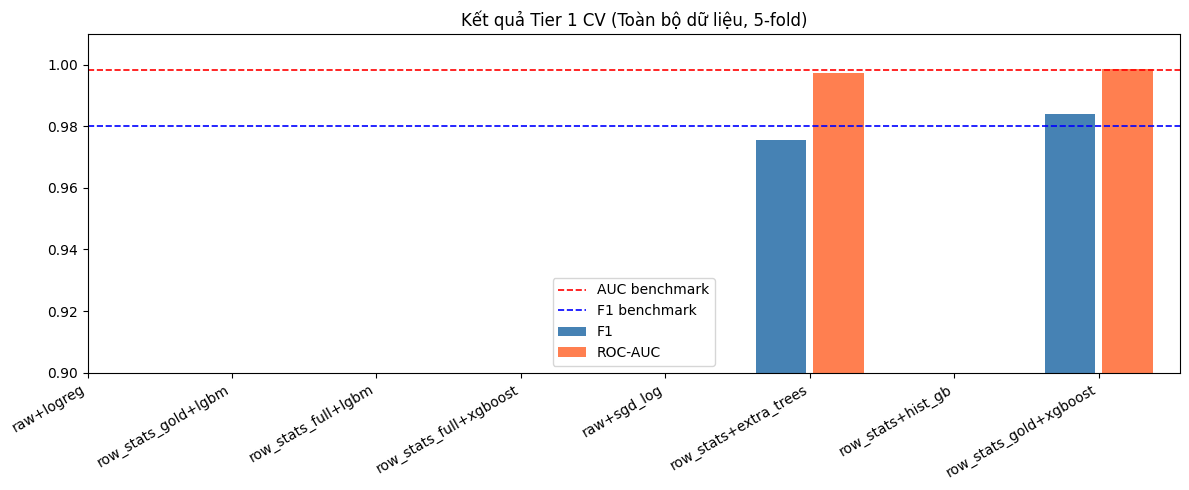

In [70]:
# Vẽ biểu đồ kết quả Tier 1
if len(tier1_results) > 0:
    tier1_results['config'] = (
        tier1_results['feature_branch_name'] + '+' + tier1_results['model_name']
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(tier1_results))
    ax.bar(x - 0.2, tier1_results['f1_mean'],      width=0.35, label='F1',     color='steelblue')
    ax.bar(x + 0.2, tier1_results['roc_auc_mean'], width=0.35, label='ROC-AUC', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(tier1_results['config'], rotation=30, ha='right')
    ax.set_ylim(0.90, 1.01)
    ax.axhline(BENCHMARK['test_lgbm_auc'], color='red',  linestyle='--', linewidth=1.2, label='AUC benchmark')
    ax.axhline(BENCHMARK['test_lgbm_f1'],  color='blue', linestyle='--', linewidth=1.2, label='F1 benchmark')
    ax.legend()
    ax.set_title('Kết quả Tier 1 CV (Toàn bộ dữ liệu, 5-fold)')
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'tier1_baseline_results.png', dpi=80)
    plt.show()


## Section 7 — Tier 2: Hyperparameter Tuning (Top-3 Models)

In [71]:
# ── Không gian tìm kiếm hyperparameter ──────────────────────────────────────
# n_estimators trong search space được giữ nhỏ (≤500) để nhanh
# Khi retrain model cuối trên 260K, sẽ override sang 1000 cây

PARAM_SPACES = {
    'lgbm': {
        'model__n_estimators':      [200, 300, 500],       # search nhanh; final=1000
        'model__learning_rate':     [0.02, 0.05, 0.08, 0.1],
        'model__num_leaves':        [63, 127, 255],        # 255 thường tốt hơn 127 trên dữ liệu lớn
        'model__max_depth':         [-1, 6, 10],
        'model__min_child_samples': [20, 50, 100],
        'model__reg_lambda':        [0.0, 0.1, 1.0],
        'model__reg_alpha':         [0.0, 0.1, 0.5],
        'model__subsample':         [0.7, 0.8, 0.9],
        'model__colsample_bytree':  [0.6, 0.8, 1.0],
        'model__colsample_bynode':  [0.6, 0.8, 1.0],      # regularization bổ sung
    },
    'xgboost': {
        'model__n_estimators':      [200, 300, 500],       # search nhanh; final=1000
        'model__max_depth':         [4, 6, 8],
        'model__learning_rate':     [0.02, 0.05, 0.1],
        'model__subsample':         [0.7, 0.8, 0.9],
        'model__colsample_bytree':  [0.6, 0.8, 1.0],
        'model__reg_alpha':         [0.0, 0.1, 1.0],
        'model__reg_lambda':        [1.0, 5.0, 10.0],
        'model__min_child_weight':  [1, 3, 5],
        'model__gamma':             [0.0, 0.1, 0.5],
    },
    'hist_gb': {
        'model__max_iter':          [200, 300, 500],       # search nhanh; final=500
        'model__max_leaf_nodes':    [63, 127, 255],
        'model__learning_rate':     [0.02, 0.05, 0.1],
        'model__l2_regularization': [0.0, 0.1, 1.0],
        'model__min_samples_leaf':  [10, 20, 50],
        'model__max_depth':         [None, 8, 15],
    },
}

# Override n_estimators khi retrain trên full 260K — nhiều cây hơn = mạnh hơn
FINAL_N_ESTIMATORS = {
    'lgbm':    {'model__n_estimators': 1000},
    'xgboost': {'model__n_estimators': 1000},
    'hist_gb': {'model__max_iter':      500},
}

print('✅ Không gian tìm kiếm hyperparameter sẵn sàng')
print(f'   TUNE_N_ITER = {TUNE_N_ITER}, TUNE_CV = {TUNE_CV}')
print(f'   Dữ liệu tune: {"Toàn bộ train" if TUNE_FULL_DATA else f"{TUNE_SAMPLE:,} mẫu subsample"}')
print(f'   Final n_estimators khi retrain: {FINAL_N_ESTIMATORS}')


✅ Không gian tìm kiếm hyperparameter sẵn sàng
   TUNE_N_ITER = 20, TUNE_CV = 3
   Dữ liệu tune: 80,000 mẫu subsample
   Final n_estimators khi retrain: {'lgbm': {'model__n_estimators': 1000}, 'xgboost': {'model__n_estimators': 1000}, 'hist_gb': {'model__max_iter': 500}}


In [72]:
 
def run_tier2(): 

    tuning_best_params = {}
    tuning_best_scores = {}

    # 1) Chuẩn bị dữ liệu tune
    if TUNE_FULL_DATA:
        X_tune, y_tune = X_train_opt, y_train
        print(f'[DATA] Tune trên toàn bộ data: {len(X_tune):,} mẫu')
    else:
        tune_X_path = RUN_CACHE_DIR / 'X_tune.parquet'
        tune_y_path = RUN_CACHE_DIR / 'y_tune.parquet'

        if tune_X_path.exists() and tune_y_path.exists():
            print('[TẢI] Đọc subsample tune từ cache')
            X_tune = pd.read_parquet(tune_X_path)
            y_tune = pd.read_parquet(tune_y_path).iloc[:, 0]
        else:
            idx_tune = np.random.RandomState(RANDOM_STATE).choice(
                len(X_train_opt),
                min(TUNE_SAMPLE, len(X_train_opt)),
                replace=False
            )
            X_tune = X_train_opt.iloc[idx_tune].copy()
            y_tune = y_train.iloc[idx_tune].copy()

            X_tune.to_parquet(tune_X_path)
            y_tune.to_frame(name='target').to_parquet(tune_y_path)
            print(f'[LƯU] Đã cache subsample tune: {len(X_tune):,} mẫu')

        print(f'[DATA] Tune trên subsample: {len(X_tune):,} mẫu')

    cv_tune = StratifiedKFold(
        n_splits=TUNE_CV,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # 2) Ưu tiên lgbm lên đầu
    top_models_for_tuning_sorted = sorted(
        TOP_MODELS_FOR_TUNING,
        key=lambda x: 0 if x['model'] == 'lgbm' else 1
    )

    # 3) Nếu thấy cache thì load xong dừng luôn
    for cfg in top_models_for_tuning_sorted:
        model_name = cfg['model']
        feat_branch = cfg['feature_branch']
        pre_name = cfg['preprocess']

        if model_name not in PARAM_SPACES:
            print(f'[BỎ QUA] Không có không gian tìm kiếm cho {model_name}')
            continue

        cache_path = RESULTS_DIR / f'tuning_{model_name}_best_params.json'

        print(f'\n{"="*60}')
        print(f'MODEL: {model_name} | feat={feat_branch} | preprocess={pre_name}')
        print(f'CACHE: {cache_path.name}')
        print(f'{"="*60}')

        if cache_path.exists():
            with open(cache_path, 'r', encoding='utf-8') as f:
                cached = json.load(f)

            tuning_best_params[model_name] = cached['best_params']
            tuning_best_scores[model_name] = cached['best_cv_auc']

            print(f'[LOAD] {model_name}')
            print(f'       AUC CV = {cached["best_cv_auc"]:.6f}')
            print(f'       Params = {cached["best_params"]}')
            print('[STOP] Đa tìm thấy cache')
            return tuning_best_params, tuning_best_scores

        # Chỉ chạy tới đây nếu chưa có cache
        print(f'[TUNING] {model_name}')
        print(f'         {TUNE_N_ITER} lần thử × {TUNE_CV} fold = {TUNE_N_ITER * TUNE_CV} lần fit')

        pipe = build_full_pipeline(pre_name, feat_branch, model_name)
        param_dist = PARAM_SPACES[model_name]

        t0 = time.time()

        rscv = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_dist,
            n_iter=TUNE_N_ITER,
            scoring='roc_auc',
            cv=cv_tune,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=1,
            refit=False,
        )

        rscv.fit(X_tune, y_tune)

        best_score = rscv.best_score_
        best_params = rscv.best_params_
        elapsed = time.time() - t0

        tuning_best_params[model_name] = best_params
        tuning_best_scores[model_name] = best_score

        with open(cache_path, 'w', encoding='utf-8') as f:
            json.dump(
                {
                    'best_params': best_params,
                    'best_cv_auc': best_score,
                    'feature_branch': feat_branch,
                    'preprocess': pre_name,
                    'n_iter': TUNE_N_ITER,
                    'n_splits': TUNE_CV,
                    'tune_sample': len(X_tune),
                },
                f,
                indent=2,
                ensure_ascii=False
            )

        print(f'[LƯU] {model_name}')
        print(f'      AUC CV tốt nhất: {best_score:.6f}')
        print(f'      Params tốt nhất: {best_params}')
        print(f'      Thời gian: {elapsed / 60:.1f} phút')

        gc.collect()

    print('\n✅ Không tìm thấy cache nào, đã chạy xong Tier 2')
    return tuning_best_params, tuning_best_scores


tuning_best_params, tuning_best_scores = run_tier2()

[TẢI] Đọc subsample tune từ cache
[DATA] Tune trên subsample: 80,000 mẫu

MODEL: lgbm | feat=row_stats_gold | preprocess=median_noscale
CACHE: tuning_lgbm_best_params.json
[LOAD] lgbm
       AUC CV = 0.998061
       Params = {'model__subsample': 0.8, 'model__reg_lambda': 0.0, 'model__reg_alpha': 0.0, 'model__num_leaves': 127, 'model__n_estimators': 500, 'model__min_child_samples': 50, 'model__max_depth': 10, 'model__learning_rate': 0.08, 'model__colsample_bytree': 0.6, 'model__colsample_bynode': 0.6}
[STOP] Đa tìm thấy cache


In [73]:
# ── Retrain model cuối trên toàn bộ 260K với params đã tune ─────────────────
# Override n_estimators sang giá trị lớn hơn (1000 cây) vì lúc search
# dùng ít cây để chạy nhanh, nhưng retrain trên full data nên dùng nhiều hơn
tuned_models = {}

for cfg in TOP_MODELS_FOR_TUNING:
    model_name  = cfg['model']
    feat_branch = cfg['feature_branch']
    pre_name    = cfg['preprocess']

    if model_name not in tuning_best_params:
        print(f'[BỎ QUA] {model_name} — chưa có kết quả tuning')
        continue

    model_pkl = MODELS_DIR / f'tuned_{model_name}.pkl'
    if model_pkl.exists():
        print(f'[TẢI] {model_name} từ {model_pkl}')
        tuned_models[model_name] = joblib.load(model_pkl)
        continue

    # Ghép params tuning + override n_estimators cho final training
    final_params = dict(tuning_best_params[model_name])
    if model_name in FINAL_N_ESTIMATORS:
        final_params.update(FINAL_N_ESTIMATORS[model_name])
        override_key = list(FINAL_N_ESTIMATORS[model_name].keys())[0]
        print(f'   [{model_name}] Override {override_key} → {FINAL_N_ESTIMATORS[model_name][override_key]} cho full training')

    print(f'Đang train {model_name} trên {len(X_train_opt):,} mẫu...')
    import time; t0 = time.time()
    pipe = build_full_pipeline(pre_name, feat_branch, model_name)
    pipe.set_params(**final_params)
    pipe.fit(X_train_opt, y_train)
    print(f'   Xong trong {(time.time()-t0)/60:.1f} phút.')

    tuned_models[model_name] = pipe
    joblib.dump(pipe, model_pkl)
    print(f'   Đã lưu → {model_pkl}')
    gc.collect()

print(f'\n✅ Models đã train: {list(tuned_models.keys())}')

expected_model_pkls = [
    MODELS_DIR / f'tuned_{cfg["model"]}.pkl'
    for cfg in TOP_MODELS_FOR_TUNING
    if cfg['model'] in tuning_best_params
]
if all(p.exists() for p in expected_model_pkls):
    mark_stage_done('tier2_trained_models',
                    {'models': [cfg['model'] for cfg in TOP_MODELS_FOR_TUNING
                                if cfg['model'] in tuning_best_params]})


[BỎ QUA] xgboost — chưa có kết quả tuning
[TẢI] lgbm từ d:\BTCK_ML\saved_models\tuned_lgbm.pkl
[BỎ QUA] hist_gb — chưa có kết quả tuning

✅ Models đã train: ['lgbm']
[CHECKPOINT] Đã hoàn thành bước: tier2_trained_models


## Section 8 — Tier 3: OOF Threshold Tuning + Evaluation

In [74]:
# ── Tier 3: Chọn ngưỡng phân loại tối ưu dựa trên OOF predictions ──────────
# Quan trọng: threshold được tune trên OOF predictions của tập TRAIN,
# KHÔNG phải trên test set — tránh data leakage vào quá trình chọn threshold

optimal_thresholds_path = RESULTS_DIR / 'optimal_thresholds.json'

if is_stage_done('tier3_oof_thresholds') and optimal_thresholds_path.exists():
    print('[BỎ QUA] Đã tune threshold từ OOF rồi.')
    optimal_thresholds = load_json(optimal_thresholds_path, {})
else:
    optimal_thresholds = {}

for model_name, pipe in tuned_models.items():
    print(f'Tính OOF probs để tune threshold: {model_name}...')
    oof_cache = RESULTS_DIR / f'oof_probs_{model_name}.npy'

    if oof_cache.exists():
        oof_probs = np.load(oof_cache)
        print(f'   [CACHE] Đã tải OOF probs.')
    else:
        # Tính OOF bằng cross_val_predict — mỗi mẫu được dự đoán bởi fold không thấy nó
        cfg = next((c for c in TOP_MODELS_FOR_TUNING if c['model'] == model_name), None)
        if cfg is None:
            continue
        oof_pipe = build_full_pipeline(cfg['preprocess'], cfg['feature_branch'], model_name)
        oof_pipe.set_params(**tuning_best_params.get(model_name, {}))
        oof_probs = cross_val_predict(
            oof_pipe, X_train_opt, y_train,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
            method='predict_proba', n_jobs=1
        )[:, 1]
        np.save(oof_cache, oof_probs)

    # Quét threshold từ 0.30 đến 0.70, bước 0.005, tìm F1 tốt nhất trên OOF
    best_thr, best_f1 = 0.5, 0.0
    for t in np.arange(0.30, 0.71, 0.005):
        f1_t = f1_score(y_train, (oof_probs >= t).astype(int))
        if f1_t > best_f1:
            best_f1, best_thr = f1_t, t

    optimal_thresholds[model_name] = best_thr
    default_f1 = f1_score(y_train, (oof_probs >= 0.5).astype(int))
    print(f'   Threshold mặc định 0.50: OOF F1={default_f1:.6f}')
    print(f'   Threshold tối ưu {best_thr:.3f}: OOF F1={best_f1:.6f} ({best_f1-default_f1:+.6f})')

print('\nNgưỡng tối ưu (từ OOF):')
for name, thr in optimal_thresholds.items():
    print(f'   {name}: {thr:.3f}')

save_json(optimal_thresholds, optimal_thresholds_path)
mark_stage_done('tier3_oof_thresholds', {
    'path': str(optimal_thresholds_path),
    'models': list(optimal_thresholds.keys())
})


[BỎ QUA] Đã tune threshold từ OOF rồi.
Tính OOF probs để tune threshold: lgbm...
   [CACHE] Đã tải OOF probs.
   Threshold mặc định 0.50: OOF F1=0.987042
   Threshold tối ưu 0.590: OOF F1=0.987223 (+0.000180)

Ngưỡng tối ưu (từ OOF):
   lgbm: 0.590
[CHECKPOINT] Đã hoàn thành bước: tier3_oof_thresholds


In [ ]:
# ── Đánh giá trên tập Test ────────────────────────────────────────────────────
test_scores_path = RESULTS_DIR / 'test_scores_summary.json'

print('=== ĐÁNH GIÁ TRÊN TẬP TEST ===')
print()

test_scores = {}  # model_name → dict metrics (có 'probs' array trong memory)

for model_name, pipe in tuned_models.items():
    thr  = optimal_thresholds.get(model_name, 0.5)
    prob = pipe.predict_proba(X_test_opt)[:, 1]
    pred = (prob >= thr).astype(int)

    # Lưu xác suất ra disk để ensemble tái sử dụng mà không cần predict lại
    prob_path = RESULTS_DIR / f'test_probs_{model_name}.npy'
    np.save(prob_path, prob)

    scores = {
        'auc':       float(roc_auc_score(y_test, prob)),
        'f1':        float(f1_score(y_test, pred)),
        'accuracy':  float(accuracy_score(y_test, pred)),
        'precision': float(precision_score(y_test, pred)),
        'recall':    float(recall_score(y_test, pred)),
        'threshold': float(thr),
        'probs':     prob,           # numpy array — giữ trong memory cho ensemble
        'probs_path': str(prob_path),
    }
    test_scores[model_name] = scores

    f1_bench  = BENCHMARK['test_lgbm_f1']
    auc_bench = BENCHMARK['test_lgbm_auc']
    f1_s  = '✅ VƯỢT' if scores['f1']  > f1_bench  else ('≈' if scores['f1']  > f1_bench  - 0.005 else '❌')
    auc_s = '✅ VƯỢT' if scores['auc'] > auc_bench else ('≈' if scores['auc'] > auc_bench - 0.001 else '❌')

    print(f'--- {model_name} (ngưỡng={thr:.3f}) ---')
    print(f'   F1:       {scores["f1"]:.6f}   ')
    print(f'   AUC:      {scores["auc"]:.6f}  ')
    print(f'   Accuracy: {scores["accuracy"]:.4f}')
    print(f'   Precision: {scores["precision"]:.4f}  Recall: {scores["recall"]:.4f}')
    print()

# Chọn model đơn tốt nhất theo AUC
best_single_name = max(test_scores, key=lambda k: test_scores[k]['auc'])
best_single      = test_scores[best_single_name]
print(f'Model đơn tốt nhất: {best_single_name} | AUC={best_single["auc"]:.6f} | F1={best_single["f1"]:.6f}')

# Lưu JSON (bỏ numpy array 'probs' vì không serialize được)
save_json({k: {kk: vv for kk, vv in v.items() if kk != 'probs'}
           for k, v in test_scores.items()}, test_scores_path)
mark_stage_done('tier3_test_eval', {'best_single_name': best_single_name})


=== ĐÁNH GIÁ TRÊN TẬP TEST ===

--- lgbm (ngưỡng=0.590) ---
   F1:       0.980415   
   AUC:      0.998174  
   Accuracy: 0.9804
   Precision: 0.9780  Recall: 0.9828

Model đơn tốt nhất: lgbm | AUC=0.998174 | F1=0.980415
[CHECKPOINT] Đã hoàn thành bước: tier3_test_eval


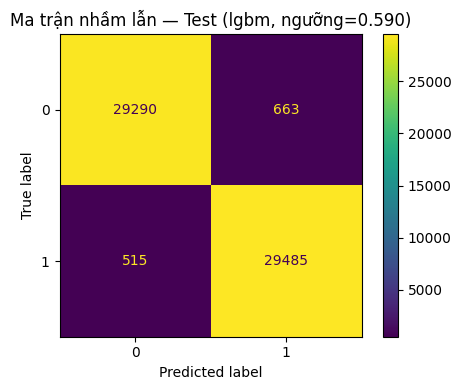

              precision    recall  f1-score   support

           0     0.9827    0.9779    0.9803     29953
           1     0.9780    0.9828    0.9804     30000

    accuracy                         0.9804     59953
   macro avg     0.9804    0.9803    0.9804     59953
weighted avg     0.9804    0.9804    0.9804     59953



In [76]:
# Ma trận nhầm lẫn cho model đơn tốt nhất
thr  = optimal_thresholds.get(best_single_name, 0.5)
prob = test_scores[best_single_name]['probs']  # numpy array trong memory
pred = (prob >= thr).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax)
ax.set_title(f'Ma trận nhầm lẫn — Test ({best_single_name}, ngưỡng={thr:.3f})')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'confusion_matrix_test.png', dpi=80)
plt.show()
print(classification_report(y_test, pred, digits=4))


In [77]:
# ── Đánh giá trên tập Challenge ──────────────────────────────────────────────
print('=== ĐÁNH GIÁ TRÊN TẬP CHALLENGE ===')

challenge_scores      = {}
challenge_scores_path = RESULTS_DIR / 'challenge_scores.json'

for model_name, pipe in tuned_models.items():
    prob = pipe.predict_proba(X_challenge_opt)[:, 1]
    try:
        chal_auc = roc_auc_score(y_challenge, prob)
        challenge_scores[model_name] = {'auc': float(chal_auc)}
        bench  = BENCHMARK['challenge_auc']
        status = '✅ VƯỢT' if chal_auc > bench else '❌'
        print(f'   {model_name}: Challenge AUC = {chal_auc:.6f}  benchmark={bench}  {status}')
    except Exception as e:
        print(f'   {model_name}: Không tính được AUC: {e}')

save_json(challenge_scores, challenge_scores_path)
mark_stage_done('tier3_challenge_eval', {'path': str(challenge_scores_path)})


=== ĐÁNH GIÁ TRÊN TẬP CHALLENGE ===
   lgbm: Challenge AUC = nan  benchmark=0.994  ❌
[CHECKPOINT] Đã hoàn thành bước: tier3_challenge_eval


## Section 9 — Ensemble (Weighted Soft-Voting)

In [78]:
# ── Ensemble có trọng số — tối ưu weights trên OOF predictions ───────────────
# Weights được tìm bằng Nelder-Mead minimize(-AUC(OOF ensemble))
# Không dùng test set để chọn weights — tránh leakage
RUN_ENSEMBLE = True

if RUN_ENSEMBLE and len(tuned_models) >= 2:
    model_names_ens = list(tuned_models.keys())

    # Stack xác suất test của tất cả models → ma trận (n_test, n_models)
    test_probs_list = [test_scores[n]['probs'] for n in model_names_ens]
    test_probs_arr  = np.stack(test_probs_list, axis=1)

    # Tải OOF probs để ztối ưu weights
    oof_probs_list, oof_ok = [], True
    for n in model_names_ens:
        cache = RESULTS_DIR / f'oof_probs_{n}.npy'
        if cache.exists():
            oof_probs_list.append(np.load(cache))
        else:
            oof_ok = False
            print(f'[CẢNH BÁO] Không tìm thấy OOF probs của {n} — dùng trọng số đều')
            break

    if oof_ok:
        oof_probs_arr = np.stack(oof_probs_list, axis=1)  # (n_train, n_models)

        def neg_oof_auc(log_weights):
            """Hàm mục tiêu: minimize -AUC của ensemble trên OOF predictions.
            Dùng log_weights để đảm bảo weights luôn dương.
            """
            weights = np.exp(log_weights)
            weights = weights / weights.sum()
            ens_prob = oof_probs_arr @ weights
            return -roc_auc_score(y_train, ens_prob)

        from scipy.optimize import minimize
        result = minimize(
            neg_oof_auc,
            x0=np.zeros(len(model_names_ens)),  # khởi tạo = trọng số đều
            method='Nelder-Mead',
            options={'maxiter': 500, 'xatol': 1e-5, 'fatol': 1e-6}
        )
        raw_weights     = np.exp(result.x)
        optimal_weights = raw_weights / raw_weights.sum()
        print('Trọng số ensemble tối ưu (từ OOF):')
        for name, w in zip(model_names_ens, optimal_weights):
            print(f'   {name}: {w:.4f}')
    else:
        optimal_weights = np.ones(len(model_names_ens)) / len(model_names_ens)
        print('Dùng trọng số đều (không có OOF probs).')

    ens_probs_test = test_probs_arr @ optimal_weights
    ens_auc        = roc_auc_score(y_test, ens_probs_test)

    # Tune threshold của ensemble cũng dựa trên OOF, không phải test
    if oof_ok:
        oof_ens_probs            = oof_probs_arr @ optimal_weights
        ens_best_thr, ens_best_f1_oof = 0.5, 0.0
        for t in np.arange(0.30, 0.71, 0.005):
            f1_t = f1_score(y_train, (oof_ens_probs >= t).astype(int))
            if f1_t > ens_best_f1_oof:
                ens_best_f1_oof, ens_best_thr = f1_t, t
        print(f'Ngưỡng ensemble (OOF-tuned): {ens_best_thr:.3f} (OOF F1={ens_best_f1_oof:.6f})')
    else:
        ens_best_thr = float(np.mean(list(optimal_thresholds.values())))

    ens_pred = (ens_probs_test >= ens_best_thr).astype(int)
    ens_f1   = f1_score(y_test, ens_pred)
    ens_acc  = accuracy_score(y_test, ens_pred)
    ens_prec = precision_score(y_test, ens_pred)
    ens_rec  = recall_score(y_test, ens_pred)

    print(f'\nEnsemble Test AUC: {ens_auc:.6f}  benchmark={BENCHMARK["test_lgbm_auc"]}')
    print(f'Ensemble Test F1:  {ens_f1:.6f}  benchmark={BENCHMARK["test_lgbm_f1"]}')

    ENSEMBLE_BEATS_SINGLE = (ens_auc > best_single['auc'] or ens_f1 > best_single['f1'])
    print(f'\nEnsemble vượt model đơn tốt nhất? {ENSEMBLE_BEATS_SINGLE}')

    chal_probs_list = [tuned_models[n].predict_proba(X_challenge_opt)[:, 1]
                       for n in model_names_ens]
    chal_probs_arr = np.stack(chal_probs_list, axis=1)
    ens_probs_chal = chal_probs_arr @ optimal_weights
    try:
        ens_chal_auc = roc_auc_score(y_challenge, ens_probs_chal)
        print(f'Ensemble Challenge AUC: {ens_chal_auc:.6f}  benchmark={BENCHMARK["challenge_auc"]}')
    except Exception as e:
        ens_chal_auc = None
        print(f'Challenge AUC không khả dụng: {e}')

    save_json({
        'model_names':      model_names_ens,
        'optimal_weights':  [float(x) for x in optimal_weights],
        'threshold':        float(ens_best_thr),
        'auc':              float(ens_auc),
        'f1':               float(ens_f1),
        'accuracy':         float(ens_acc),
        'precision':        float(ens_prec),
        'recall':           float(ens_rec),
        'challenge_auc':    float(ens_chal_auc) if ens_chal_auc is not None else None,
    }, RESULTS_DIR / 'ensemble_meta.json')
    mark_stage_done('ensemble_done', {})

elif RUN_ENSEMBLE and len(tuned_models) == 1:
    # Chỉ có 1 model — ensemble không có ý nghĩa
    ENSEMBLE_BEATS_SINGLE = False
    model_names_ens = list(tuned_models.keys())
    print(f'Chỉ có 1 model ({model_names_ens[0]}) — bỏ qua ensemble.')

else:
    ENSEMBLE_BEATS_SINGLE = False
    model_names_ens = list(tuned_models.keys())
    print('Ensemble bị bỏ qua.')


Chỉ có 1 model (lgbm) — bỏ qua ensemble.


## Section 10 — Final Summary

In [79]:
# ── Xác định kết quả cuối cùng ───────────────────────────────────────────────
if RUN_ENSEMBLE and ENSEMBLE_BEATS_SINGLE:
    final_name     = 'ensemble(' + '+'.join(model_names_ens) + ')'
    final_auc      = ens_auc
    final_f1       = ens_f1
    final_acc      = ens_acc
    final_prec     = ens_prec
    final_rec      = ens_rec
    final_thr      = ens_best_thr
    final_chal_auc = ens_chal_auc if 'ens_chal_auc' in locals() else None
else:
    final_name  = best_single_name
    final_auc   = best_single['auc']
    final_f1    = best_single['f1']
    final_acc   = best_single['accuracy']
    final_prec  = best_single['precision']
    final_rec   = best_single['recall']
    final_thr   = optimal_thresholds.get(best_single_name, 0.5)
    try:
        _p = tuned_models[best_single_name].predict_proba(X_challenge_opt)[:, 1]
        final_chal_auc = roc_auc_score(y_challenge, _p)
    except Exception:
        final_chal_auc = None

print('='*70)
print(' KẾT QUẢ CUỐI CÙNG — v2')
print('='*70)
print(f'Model cuối:  {final_name}')
print(f'Ngưỡng:      {final_thr:.3f}  (tune từ OOF, không phải test set)')
print()

def status(val, bench):
    if val > bench:          return '✅ VƯỢT'
    if val > bench - 0.003: return '≈ GẦN'
    return '❌ CHƯA ĐẠT'

rows = [
    ('F1',        final_f1,  BENCHMARK['test_lgbm_f1'],  'LightGBM'),
    ('AUC',       final_auc, BENCHMARK['test_lgbm_auc'], 'LightGBM'),
    ('Accuracy',  final_acc, BENCHMARK['test_accuracy'], 'baseline'),
]
print(f'{"Metric":<12} {"Của ta":<10} {"Benchmark":<12} {"Ref":<12} Trạng thái')
print('-'*62)
for metric, val, bench, ref in rows:
    print(f'{metric:<12} {val:.6f}   {bench:.4f}       {ref:<12} {status(val, bench)}')
print()
print(f'Precision: {final_prec:.4f}  Recall: {final_rec:.4f}')
if final_chal_auc:
    bench_c = BENCHMARK['challenge_auc']
    print(f'Challenge AUC: {final_chal_auc:.6f}  benchmark={bench_c}  {status(final_chal_auc, bench_c)}')
print('='*70)

meta = {
    'timestamp':        datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'final_model':      final_name,
    'threshold':        float(final_thr),
    'tuning_n_iter':    TUNE_N_ITER,
    'tuning_cv':        TUNE_CV,
    'tuning_full_data': TUNE_FULL_DATA,
    'tune_sample':      TUNE_SAMPLE,
    'test_f1':          float(final_f1),
    'test_auc':         float(final_auc),
    'test_accuracy':    float(final_acc),
    'test_precision':   float(final_prec),
    'test_recall':      float(final_rec),
    'challenge_auc':    float(final_chal_auc) if final_chal_auc else None,
    'beats_lgbm_f1':    bool(final_f1  > BENCHMARK['test_lgbm_f1']),
    'beats_lgbm_auc':   bool(final_auc > BENCHMARK['test_lgbm_auc']),
}
with open(OUTPUTS_DIR / 'final_model_meta_v2.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('✅ Đã lưu metadata → final_model_meta_v2.json')
mark_stage_done('final_summary_done', {'final_model': final_name})


 KẾT QUẢ CUỐI CÙNG — v2
Model cuối:  lgbm
Ngưỡng:      0.590  (tune từ OOF, không phải test set)

Metric       Của ta     Benchmark    Ref          Trạng thái
--------------------------------------------------------------
F1           0.980415   0.9801       LightGBM     ✅ VƯỢT
AUC          0.998174   0.9981       LightGBM     ✅ VƯỢT
Accuracy     0.980351   0.9655       baseline     ✅ VƯỢT

Precision: 0.9780  Recall: 0.9828
Challenge AUC: nan  benchmark=0.994  ❌ CHƯA ĐẠT
✅ Đã lưu metadata → final_model_meta_v2.json
[CHECKPOINT] Đã hoàn thành bước: final_summary_done


In [80]:
try:
    _ = X_test.shape
    print(f"[OK] X_test đã có trong bộ nhớ: {X_test.shape}")
except NameError:
    print("[LOAD] Không tìm thấy X_test — đang tải từ file Parquet...")
    X_test = load_parquet(TEST_PARQUET_DIR)
    print(f"       Đã tải X_test: {X_test.shape}")

try:
    _ = X_challenge.shape
    print(f"[OK] X_challenge đã có trong bộ nhớ: {X_challenge.shape}")
except NameError:
    print("[LOAD] Không tìm thấy X_challenge — đang tải từ file Parquet...")
    X_challenge = load_parquet(CHALLENGE_PARQUET_DIR)
    print(f"       Đã tải X_challenge: {X_challenge.shape}")

try:
    _ = y_test.shape
    print(f"[OK] y_test đã có trong bộ nhớ")
except NameError:
    print("[LOAD] Không tìm thấy y_test — đang tải từ file CSV...")
    y_test = pd.read_csv(TEST_Y_CSV).iloc[:, 0]

try:
    _ = y_challenge.shape
    print(f"[OK] y_challenge đã có trong bộ nhớ")
except NameError:
    print("[LOAD] Không tìm thấy y_challenge — đang tải từ file CSV...")
    y_challenge = pd.read_csv(CHALLENGE_Y_CSV).iloc[:, 0]

gc.collect()
print("\nTất cả dữ liệu yêu cầu đã sẵn sàng. ✓")

# ── 1. Tạo domain label ────────────────────────────────────────────────────
# test      → domain label 0
# challenge → domain label 1

y_test_domain      = pd.Series(np.zeros(len(X_test),      dtype=int), name="domain")
y_challenge_domain = pd.Series(np.ones(len(X_challenge),  dtype=int), name="domain")

print(f"\n[1] Đã tạo domain labels:")
print(f"    y_test_domain      : {len(y_test_domain):,} mẫu — nhãn 0")
print(f"    y_challenge_domain : {len(y_challenge_domain):,} mẫu — nhãn 1")

# ── 2. Ghép dữ liệu ────────────────────────────────────────────────────────
X_eval_shift = pd.concat(
    [X_test.reset_index(drop=True),
     X_challenge.reset_index(drop=True)],
    axis=0,
    ignore_index=True
)

y_eval_shift = pd.concat(
    [y_test_domain,
     y_challenge_domain],
    axis=0,
    ignore_index=True
)

print(f"\n[2] Dữ liệu đã gộp (X_eval_shift / y_eval_shift):")
print(f"    X_eval_shift : {X_eval_shift.shape}")
print(f"    y_eval_shift : {y_eval_shift.shape}")
print(f"    Phân bổ nhãn:\n{y_eval_shift.value_counts().rename({0: 'test (0)', 1: 'challenge (1)'}).to_string()}")
print(f"    Cân bằng lớp: {y_eval_shift.mean():.4f}  (1.0 = toàn bộ là challenge, 0.0 = toàn bộ là test)")

# ── 3. Sanity checks ───────────────────────────────────────────────────────
assert len(X_eval_shift) == len(y_eval_shift), "Độ dài X và y không khớp sau khi gộp!"
assert X_eval_shift.shape[1] == X_test.shape[1], "Số lượng cột không khớp!"
assert set(y_eval_shift.unique()) == {0, 1}, "Giá trị nhãn không hợp lệ!"
print(f"\n[3] Đã kiểm tra tính hợp lệ thành công. ✓")

gc.collect()

[LOAD] Không tìm thấy X_test — đang tải từ file Parquet...
       Đã tải X_test: (59953, 2568)
[LOAD] Không tìm thấy X_challenge — đang tải từ file Parquet...
       Đã tải X_challenge: (6315, 2568)
[OK] y_test đã có trong bộ nhớ
[OK] y_challenge đã có trong bộ nhớ

Tất cả dữ liệu yêu cầu đã sẵn sàng. ✓

[1] Đã tạo domain labels:
    y_test_domain      : 59,953 mẫu — nhãn 0
    y_challenge_domain : 6,315 mẫu — nhãn 1

[2] Dữ liệu đã gộp (X_eval_shift / y_eval_shift):
    X_eval_shift : (66268, 2568)
    y_eval_shift : (66268,)
    Phân bổ nhãn:
domain
test (0)         59953
challenge (1)     6315
    Cân bằng lớp: 0.0953  (1.0 = toàn bộ là challenge, 0.0 = toàn bộ là test)

[3] Đã kiểm tra tính hợp lệ thành công. ✓


0

In [83]:
# ── Train LightGBM nhẹ để detect distribution shift ────────────────────
shift_detector = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

cv_shift = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# OOF probabilities — xác suất sample thuộc challenge (label=1)
oof_probs_shift = cross_val_predict(
    shift_detector,
    X_eval_shift,
    y_eval_shift,
    cv=cv_shift,
    method="predict_proba",
    n_jobs=CV_N_JOBS,
)[:, 1]

shift_pred = (oof_probs_shift >= 0.5).astype(int)

#
shift_acc = accuracy_score(y_eval_shift, shift_pred)
shift_precision = precision_score(y_eval_shift, shift_pred, zero_division=0)
shift_recall = recall_score(y_eval_shift, shift_pred, zero_division=0)
shift_f1 = f1_score(y_eval_shift, shift_pred, zero_division=0)
shift_auc = roc_auc_score(y_eval_shift, oof_probs_shift)

print('=== ĐÁNH GIÁ TRÊN TẬP KẾT HỢP ===')

print(f'--- {model_name} (ngưỡng={thr:.3f}) ---')
print(f'   F1:       {shift_f1:.6f}  ')
print(f'   AUC:      {shift_auc:.6f}')
print(f'   Accuracy: {scores["accuracy"]:.4f}')
print(f'   Precision: {shift_precision:.6f}  Recall: {shift_recall:.6f}')
print()
  
# ── Save result ─────────────────────────────────────────────────────────
shift_result = {
    "accuracy": float(shift_acc),
    "precision": float(shift_precision),
    "recall": float(shift_recall),
    "f1": float(shift_f1),
    "auc": float(shift_auc),
    "n_test_samples": int(len(X_test)),
    "n_challenge_samples": int(len(X_challenge)),
    "cv_folds": int(N_SPLITS),
}

shift_result_path = RESULTS_DIR / "shift_detection_result.json"
with open(shift_result_path, "w", encoding="utf-8") as f:
    json.dump(shift_result, f, indent=2, ensure_ascii=False)

print(f"\nĐã lưu metrics → {shift_result_path}")

gc.collect()

=== ĐÁNH GIÁ TRÊN TẬP KẾT HỢP ===
--- lgbm (ngưỡng=0.590) ---
   F1:       0.980449  
   AUC:      0.995495
   Accuracy: 0.9804
   Precision: 0.996565  Recall: 0.964846


Đã lưu metrics → d:\BTCK_ML\results\shift_detection_result.json


100